In [ ]:
# Install required libraries
!pip install pandas numpy nltk beautifulsoup4 scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
import re
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package wordnet to /Users/sohail/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sohail/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/sohail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/sohail/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [3]:
# Dataset path
DATA_PATH = "amazon_reviews_us_Office_Products_v1_00.tsv"

# Dataset Preparation

## Read Data

In [4]:
# Read the TSV file
df = pd.read_csv(DATA_PATH, sep='\t', on_bad_lines='skip')

# Display basic info
print(f"Total reviews loaded: {len(df)}")
print(f"\nColumns in dataset: {df.columns.tolist()}")

Total reviews loaded: 2640254

Columns in dataset: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date']


## Keep Reviews and Ratings

In [5]:
# Keep only review_body and star_rating columns
df = df[['review_body', 'star_rating']].copy()

# Drop rows with missing values
df = df.dropna()

# Convert star_rating to numeric (in case it's not)
df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')
df = df.dropna()
df['star_rating'] = df['star_rating'].astype(int)

# Display three sample reviews with ratings
print("Three Sample Reviews with Ratings:")
print("="*60)
for i, (idx, row) in enumerate(df.head(3).iterrows()):
    print(f"\nReview {i+1}:")
    print(f"Rating: {row['star_rating']} stars")
    print(f"Review: {row['review_body'][:200]}...")
    print("-"*60)

# Statistics of ratings
print("\n\nRating Statistics:")
print("="*60)
rating_counts = df['star_rating'].value_counts().sort_index()
for rating, count in rating_counts.items():
    print(f"{int(rating)}-star reviews: {count}")

Three Sample Reviews with Ratings:

Review 1:
Rating: 5 stars
Review: Great product....
------------------------------------------------------------

Review 2:
Rating: 5 stars
Review: What's to say about this commodity item except, what have we come to in this world.<br />Having the need to bnuy captured and compressed air. &#60;lol&#62;...
------------------------------------------------------------

Review 3:
Rating: 5 stars
Review: Haven't used yet, but I am sure I will like it....
------------------------------------------------------------


Rating Statistics:
1-star reviews: 306967
2-star reviews: 138381
3-star reviews: 193680
4-star reviews: 418348
5-star reviews: 1582704


 ## Relabeling and Sampling
 
First form three classes and print their statistics. Then randomly select 100,000 reviews from the positive and 100,000 reviews from the negative

In [6]:
# Create three classes based on ratings
# Positive: rating > 3 (4, 5)
# Negative: rating <= 2 (1, 2)
# Neutral: rating == 3 (will be discarded)

positive_df = df[df['star_rating'] > 3].copy()
negative_df = df[df['star_rating'] <= 2].copy()
neutral_df = df[df['star_rating'] == 3].copy()

# Print statistics for three classes
print("Class Statistics:")
print(f"Positive reviews: {len(positive_df)}")
print(f"Negative reviews: {len(negative_df)}")
print(f"Neutral reviews: {len(neutral_df)}")

# Sample 100,000 from each class (positive and negative)
positive_sample = positive_df.sample(n=100000, random_state=42)
negative_sample = negative_df.sample(n=100000, random_state=42)

# Assign binary labels
positive_sample['label'] = 1
negative_sample['label'] = 0

# Combine the samples
df_balanced = pd.concat([positive_sample, negative_sample], ignore_index=True)

# Shuffle the combined dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset size: {len(df_balanced)}")
print(f"Positive samples: {len(df_balanced[df_balanced['label'] == 1])}")
print(f"Negative samples: {len(df_balanced[df_balanced['label'] == 0])}")

Class Statistics:
Positive reviews: 2001052
Negative reviews: 445348
Neutral reviews: 193680

Balanced dataset size: 200000
Positive samples: 100000
Negative samples: 100000


# Data Cleaning

In [7]:
# Contractions dictionary
contractions_dict = {
    "won't": "will not", "can't": "cannot", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'ve": " have", "'m": " am",
    "let's": "let us", "it's": "it is", "i'm": "i am", "you're": "you are",
    "he's": "he is", "she's": "she is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'd": "i would", "you'd": "you would", "he'd": "he would", "she'd": "she would",
    "we'd": "we would", "they'd": "they would", "i'll": "i will", "you'll": "you will",
    "he'll": "he will", "she'll": "she will", "we'll": "we will", "they'll": "they will",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "doesn't": "does not", "don't": "do not", "didn't": "did not",
    "wouldn't": "would not", "shouldn't": "should not", "couldn't": "could not",
    "mightn't": "might not", "mustn't": "must not", "needn't": "need not",
    "shan't": "shall not", "wasn't": "was not", "weren't": "were not",
    "what's": "what is", "who's": "who is", "where's": "where is",
    "when's": "when is", "why's": "why is", "how's": "how is",
    "that's": "that is", "there's": "there is", "here's": "here is",
    "what'll": "what will", "who'll": "who will", "where'll": "where will",
    "what've": "what have", "who've": "who have", "could've": "could have",
    "would've": "would have", "should've": "should have", "might've": "might have",
    "must've": "must have", "y'all": "you all", "ain't": "is not",
    "gonna": "going to", "gotta": "got to", "wanna": "want to",
    "kinda": "kind of", "sorta": "sort of", "lemme": "let me", "gimme": "give me"
}

# Compile contractions pattern
contractions_pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())), 
                                   flags=re.IGNORECASE)

def expand_contractions(text):
    def replace(match):
        return contractions_dict.get(match.group(0).lower(), match.group(0))
    return contractions_pattern.sub(replace, text)

def clean_text(text):
    # Handle non-string values
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags using BeautifulSoup
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Expand contractions
    text = expand_contractions(text)
    
    # Remove non-alphabetical characters (keep spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Calculate average length before cleaning
avg_length_before_cleaning = df_balanced['review_body'].astype(str).apply(len).mean()
print(f"Average length before cleaning: {avg_length_before_cleaning:.4f}")

# Apply cleaning
df_balanced['cleaned_review'] = df_balanced['review_body'].apply(clean_text)

# Calculate average length after cleaning
avg_length_after_cleaning = df_balanced['cleaned_review'].apply(len).mean()
print(f"Average length after cleaning: {avg_length_after_cleaning:.4f}")

# Show sample before and after
print("\n\nSample Reviews - Before and After Cleaning:")
print("="*60)
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"BEFORE: {df_balanced['review_body'].iloc[i][:150]}...")
    print(f"AFTER:  {df_balanced['cleaned_review'].iloc[i][:150]}...")
    print("-"*60)

Average length before cleaning: 318.0072
Average length after cleaning: 302.9584


Sample Reviews - Before and After Cleaning:

Sample 1:
BEFORE: This ink did not work on my Epson WF-2630.  Printer would not recognize and therefore would not print.  Tried various times, rebooted printer etc...Th...
AFTER:  this ink did not work on my epson wf printer would not recognize and therefore would not print tried various times rebooted printer etc the customer s...
------------------------------------------------------------

Sample 2:
BEFORE: These chalk markers have a great medium sized tip and erase well with a wet cloth.  So far, I'm loving them and I hope they last throughout the school...
AFTER:  these chalk markers have a great medium sized tip and erase well with a wet cloth so far i am loving them and i hope they last throughout the school y...
------------------------------------------------------------

Sample 3:
BEFORE: The ink runs out too fast. Not very good product....
AFTER:  t

# Pre-processing

## remove the stop words 

In [8]:
from nltk.corpus import stopwords

# Get English stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Store cleaned review before preprocessing for comparison
df_balanced['before_preprocessing'] = df_balanced['cleaned_review'].copy()

## perform lemmatization  

In [9]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

def preprocess_text(text):
    # Remove stopwords
    text = remove_stopwords(text)
    # Lemmatize
    text = lemmatize_text(text)
    return text

# Calculate average length before preprocessing
avg_length_before_preprocessing = df_balanced['cleaned_review'].apply(len).mean()
print(f"Average length before preprocessing: {avg_length_before_preprocessing:.4f}")

# Apply preprocessing
df_balanced['preprocessed_review'] = df_balanced['cleaned_review'].apply(preprocess_text)

# Calculate average length after preprocessing
avg_length_after_preprocessing = df_balanced['preprocessed_review'].apply(len).mean()
print(f"Average length after preprocessing: {avg_length_after_preprocessing:.4f}")

# Show three sample reviews before and after data cleaning + preprocessing
print("\n\nThree Sample Reviews - Before and After Data Cleaning + Preprocessing:")
print("="*80)
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"ORIGINAL:      {df_balanced['review_body'].iloc[i][:100]}...")
    print(f"AFTER CLEAN:   {df_balanced['cleaned_review'].iloc[i][:100]}...")
    print(f"AFTER PREPROC: {df_balanced['preprocessed_review'].iloc[i][:100]}...")
    print("-"*80)

Average length before preprocessing: 302.9584
Average length after preprocessing: 187.4218


Three Sample Reviews - Before and After Data Cleaning + Preprocessing:

Sample 1:
ORIGINAL:      This ink did not work on my Epson WF-2630.  Printer would not recognize and therefore would not prin...
AFTER CLEAN:   this ink did not work on my epson wf printer would not recognize and therefore would not print tried...
AFTER PREPROC: ink work epson wf printer would recognize therefore would print tried various time rebooted printer ...
--------------------------------------------------------------------------------

Sample 2:
ORIGINAL:      These chalk markers have a great medium sized tip and erase well with a wet cloth.  So far, I'm lovi...
AFTER CLEAN:   these chalk markers have a great medium sized tip and erase well with a wet cloth so far i am loving...
AFTER PREPROC: chalk marker great medium sized tip erase well wet cloth far loving hope last throughout school year...
-------------------

# Bigram Feature Extraction

In [10]:
# Extract Bigram features using CountVectorizer
# ngram_range=(2,2) means only bigrams

vectorizer = CountVectorizer(ngram_range=(2, 2))

# Fit and transform the preprocessed reviews
X = vectorizer.fit_transform(df_balanced['preprocessed_review'])
y = df_balanced['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Number of bigram features: {X.shape[1]}")

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Feature matrix shape: (200000, 1836589)
Number of bigram features: 1836589

Training set size: 160000
Testing set size: 40000


# Perceptron

In [11]:
# Helper function to print metrics
def print_metrics(model_name, y_true, y_pred, split_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"{model_name} {split_name} Accuracy: {accuracy:.4f}")
    print(f"{model_name} {split_name} Precision: {precision:.4f}")
    print(f"{model_name} {split_name} Recall: {recall:.4f}")
    print(f"{model_name} {split_name} F1-score: {f1:.4f}")
    
    return accuracy, precision, recall, f1

# Train Perceptron model
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)

# Predictions
y_train_pred_perceptron = perceptron.predict(X_train)
y_test_pred_perceptron = perceptron.predict(X_test)

# Print metrics
print("="*50)
print("PERCEPTRON RESULTS")
print("="*50)
print_metrics("Perceptron", y_train, y_train_pred_perceptron, "Training")
print()
print_metrics("Perceptron", y_test, y_test_pred_perceptron, "Testing")

PERCEPTRON RESULTS
Perceptron Training Accuracy: 0.9894
Perceptron Training Precision: 0.9833
Perceptron Training Recall: 0.9958
Perceptron Training F1-score: 0.9895

Perceptron Testing Accuracy: 0.8572
Perceptron Testing Precision: 0.8409
Perceptron Testing Recall: 0.8829
Perceptron Testing F1-score: 0.8614


(0.85725, 0.8409327898378993, 0.8828622611464968, 0.8613875807156381)

# SVM

In [12]:
# Train SVM model (using LinearSVC for efficiency)
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)

# Predictions
y_train_pred_svm = svm.predict(X_train)
y_test_pred_svm = svm.predict(X_test)

# Print metrics
print("="*50)
print("SVM RESULTS")
print("="*50)
print_metrics("SVM", y_train, y_train_pred_svm, "Training")
print()
print_metrics("SVM", y_test, y_test_pred_svm, "Testing")

SVM RESULTS
SVM Training Accuracy: 0.9917
SVM Training Precision: 0.9840
SVM Training Recall: 0.9996
SVM Training F1-score: 0.9918

SVM Testing Accuracy: 0.8457
SVM Testing Precision: 0.8134
SVM Testing Recall: 0.8989
SVM Testing F1-score: 0.8541


(0.84565, 0.8134456051873199, 0.8989351114649682, 0.8540563540090772)

# Logistic Regression

In [13]:
# Train Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Print metrics
print("="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print_metrics("Logistic Regression", y_train, y_train_pred_lr, "Training")
print()
print_metrics("Logistic Regression", y_test, y_test_pred_lr, "Testing")

LOGISTIC REGRESSION RESULTS
Logistic Regression Training Accuracy: 0.9843
Logistic Regression Training Precision: 0.9719
Logistic Regression Training Recall: 0.9973
Logistic Regression Training F1-score: 0.9845

Logistic Regression Testing Accuracy: 0.8678
Logistic Regression Testing Precision: 0.8377
Logistic Regression Testing Recall: 0.9139
Logistic Regression Testing F1-score: 0.8742


(0.8678, 0.837712096332786, 0.9139132165605095, 0.8741551642075203)

# Naive Bayes

In [14]:
# Train Multinomial Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predictions
y_train_pred_nb = nb.predict(X_train)
y_test_pred_nb = nb.predict(X_test)

# Print metrics
print("="*50)
print("NAIVE BAYES RESULTS")
print("="*50)
print_metrics("Naive Bayes", y_train, y_train_pred_nb, "Training")
print()
print_metrics("Naive Bayes", y_test, y_test_pred_nb, "Testing")

NAIVE BAYES RESULTS
Naive Bayes Training Accuracy: 0.9453
Naive Bayes Training Precision: 0.9722
Naive Bayes Training Recall: 0.9166
Naive Bayes Training F1-score: 0.9436

Naive Bayes Testing Accuracy: 0.8387
Naive Bayes Testing Precision: 0.8396
Naive Bayes Testing Recall: 0.8392
Naive Bayes Testing F1-score: 0.8394


(0.83865, 0.8395897640147366, 0.839171974522293, 0.8393808172813698)

---
# Advanced Analysis and Visualizations

The following sections provide deeper insights into model performance through visualizations and error analysis.

In [15]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set style for better looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## Confusion Matrices

Confusion matrices provide a detailed view of model predictions, showing true positives, true negatives, false positives, and false negatives.

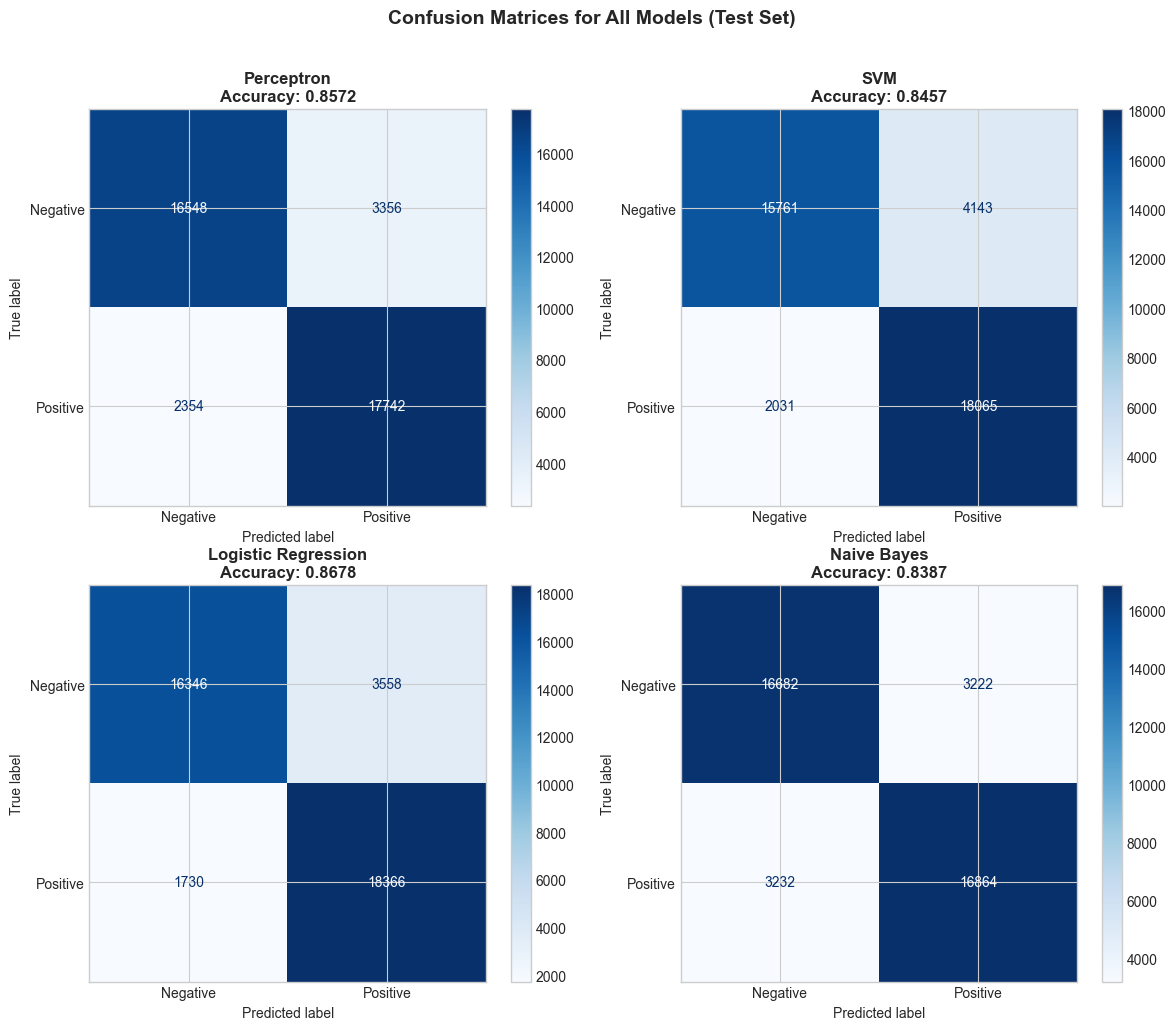

In [16]:
# Create confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_data = [
    ('Perceptron', y_test_pred_perceptron),
    ('SVM', y_test_pred_svm),
    ('Logistic Regression', y_test_pred_lr),
    ('Naive Bayes', y_test_pred_nb)
]

for ax, (name, y_pred) in zip(axes.flat, models_data):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices for All Models (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Performance Comparison

A visual comparison of all models across key metrics helps identify the best performer at a glance.

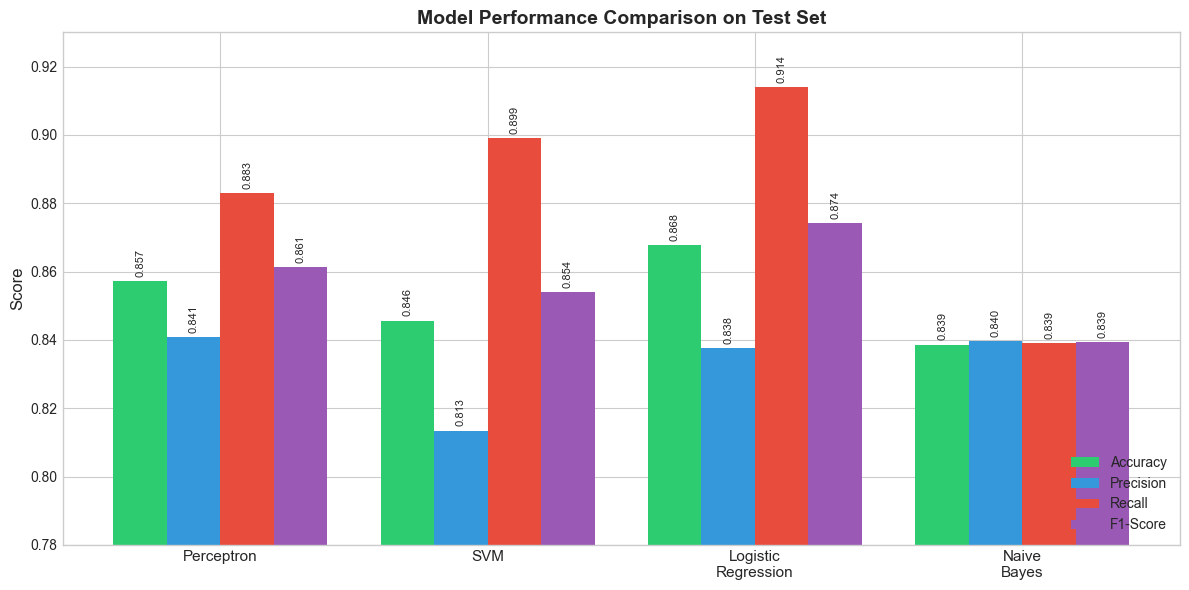


Best Model: Logistic Regression with F1-Score: 0.8742


In [17]:
# Model comparison visualization
models = ['Perceptron', 'SVM', 'Logistic\nRegression', 'Naive\nBayes']

# Calculate metrics for each model
metrics_data = {
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_perceptron),
        accuracy_score(y_test, y_test_pred_svm),
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_perceptron),
        precision_score(y_test, y_test_pred_svm),
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_perceptron),
        recall_score(y_test, y_test_pred_svm),
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_perceptron),
        f1_score(y_test, y_test_pred_svm),
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_nb)
    ]
}

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - 1.5*width, metrics_data['Accuracy'], width, label='Accuracy', color='#2ecc71')
bars2 = ax.bar(x - 0.5*width, metrics_data['Precision'], width, label='Precision', color='#3498db')
bars3 = ax.bar(x + 0.5*width, metrics_data['Recall'], width, label='Recall', color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, metrics_data['F1-Score'], width, label='F1-Score', color='#9b59b6')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0.78, 0.93)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best model
best_idx = np.argmax(metrics_data['F1-Score'])
print(f"\nBest Model: {models[best_idx].replace(chr(10), ' ')} with F1-Score: {metrics_data['F1-Score'][best_idx]:.4f}")

## Top Bigrams Analysis

Analyzing the most influential bigrams for positive and negative sentiment provides interpretable insights into what the model has learned.

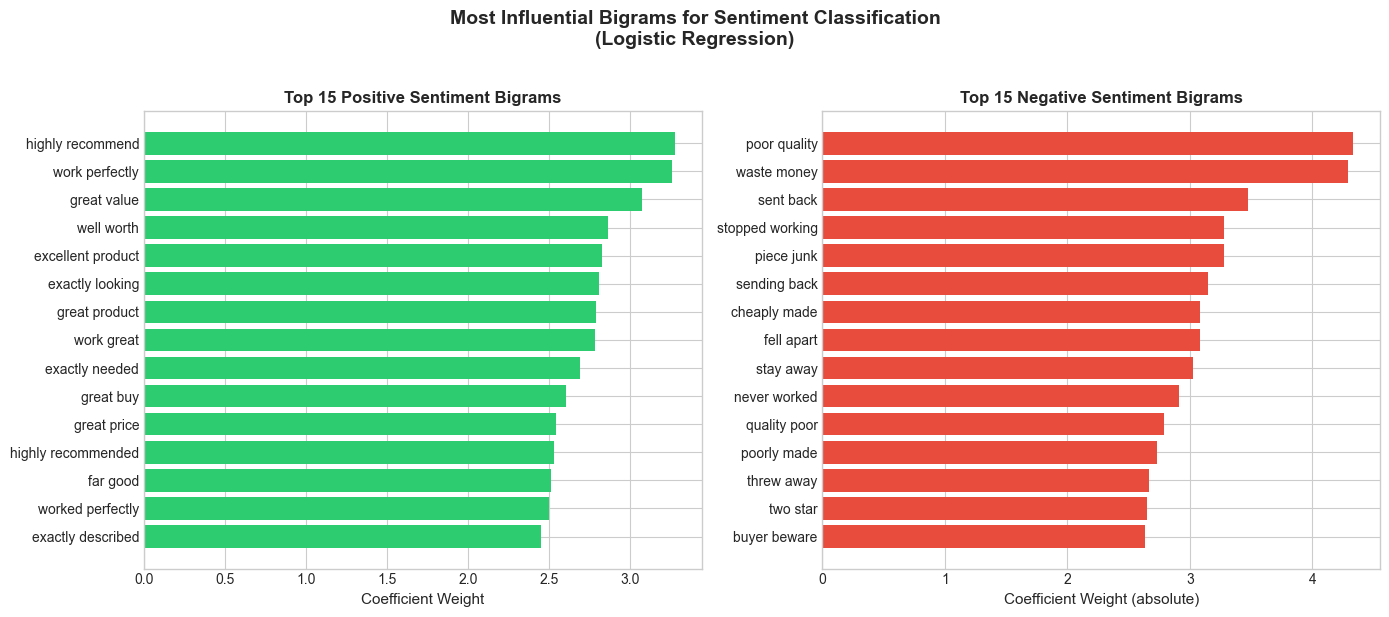


Top 15 Positive Sentiment Bigrams:
  'highly recommend': 3.2758
  'work perfectly': 3.2550
  'great value': 3.0749
  'well worth': 2.8632
  'excellent product': 2.8235
  'exactly looking': 2.8074
  'great product': 2.7900
  'work great': 2.7797
  'exactly needed': 2.6919
  'great buy': 2.6017
  'great price': 2.5411
  'highly recommended': 2.5265
  'far good': 2.5123
  'worked perfectly': 2.4980
  'exactly described': 2.4503

Top 15 Negative Sentiment Bigrams:
  'poor quality': -4.3359
  'waste money': -4.2892
  'sent back': -3.4750
  'stopped working': -3.2821
  'piece junk': -3.2811
  'sending back': -3.1518
  'cheaply made': -3.0851
  'fell apart': -3.0818
  'stay away': -3.0237
  'never worked': -2.9139
  'quality poor': -2.7929
  'poorly made': -2.7320
  'threw away': -2.6629
  'two star': -2.6542
  'buyer beware': -2.6362


In [18]:
# Extract top bigrams from Logistic Regression (best model)
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_[0]

# Get indices of top positive and negative bigrams
top_positive_idx = coefs.argsort()[-15:][::-1]
top_negative_idx = coefs.argsort()[:15]

top_positive_bigrams = [(feature_names[i], coefs[i]) for i in top_positive_idx]
top_negative_bigrams = [(feature_names[i], coefs[i]) for i in top_negative_idx]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive bigrams
pos_bigrams = [b[0] for b in top_positive_bigrams]
pos_weights = [b[1] for b in top_positive_bigrams]
axes[0].barh(pos_bigrams, pos_weights, color='#2ecc71')
axes[0].set_xlabel('Coefficient Weight', fontsize=11)
axes[0].set_title('Top 15 Positive Sentiment Bigrams', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Negative bigrams
neg_bigrams = [b[0] for b in top_negative_bigrams]
neg_weights = [abs(b[1]) for b in top_negative_bigrams]
axes[1].barh(neg_bigrams, neg_weights, color='#e74c3c')
axes[1].set_xlabel('Coefficient Weight (absolute)', fontsize=11)
axes[1].set_title('Top 15 Negative Sentiment Bigrams', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Most Influential Bigrams for Sentiment Classification\n(Logistic Regression)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the bigrams
print("\nTop 15 Positive Sentiment Bigrams:")
for bigram, weight in top_positive_bigrams:
    print(f"  '{bigram}': {weight:.4f}")

print("\nTop 15 Negative Sentiment Bigrams:")
for bigram, weight in top_negative_bigrams:
    print(f"  '{bigram}': {weight:.4f}")

## Overfitting Analysis

Comparing training vs testing performance reveals the generalization capability of each model.

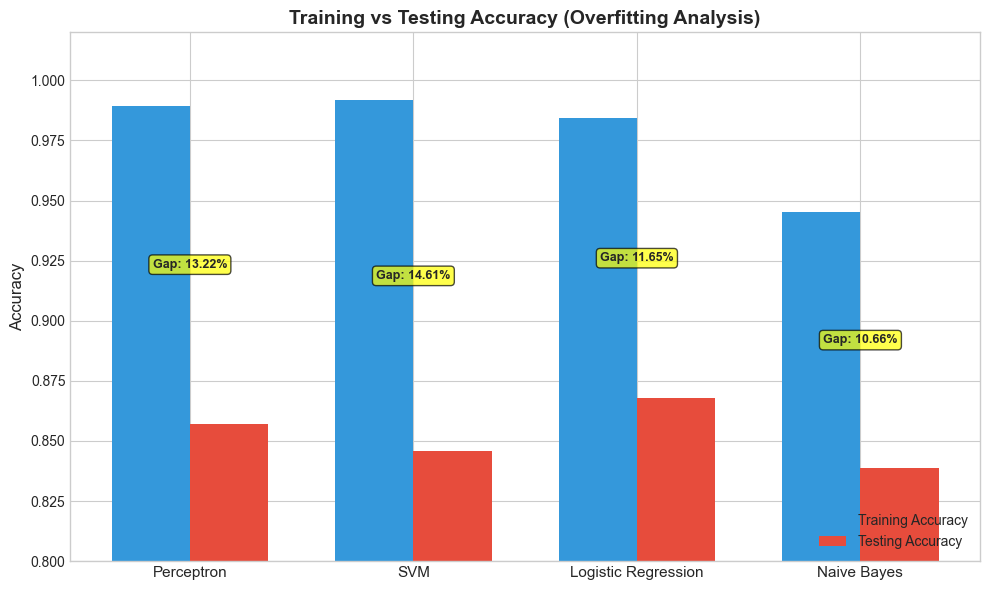


Overfitting Summary:
------------------------------------------------------------
Model                  Train Acc    Test Acc     Gap         
------------------------------------------------------------
Perceptron             0.9894       0.8572       13.22%      
SVM                    0.9917       0.8457       14.61%      
Logistic Regression    0.9843       0.8678       11.65%      
Naive Bayes            0.9453       0.8387       10.66%      
------------------------------------------------------------

Naive Bayes shows the least overfitting (best generalization)
Logistic Regression achieves the best test accuracy despite moderate overfitting


In [19]:
# Overfitting Analysis - Training vs Testing Accuracy
models_names = ['Perceptron', 'SVM', 'Logistic Regression', 'Naive Bayes']

train_accuracies = [
    accuracy_score(y_train, y_train_pred_perceptron),
    accuracy_score(y_train, y_train_pred_svm),
    accuracy_score(y_train, y_train_pred_lr),
    accuracy_score(y_train, y_train_pred_nb)
]

test_accuracies = [
    accuracy_score(y_test, y_test_pred_perceptron),
    accuracy_score(y_test, y_test_pred_svm),
    accuracy_score(y_test, y_test_pred_lr),
    accuracy_score(y_test, y_test_pred_nb)
]

overfitting_gap = [train - test for train, test in zip(train_accuracies, test_accuracies)]

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='#3498db')
bars2 = ax.bar(x + width/2, test_accuracies, width, label='Testing Accuracy', color='#e74c3c')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training vs Testing Accuracy (Overfitting Analysis)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0.8, 1.02)

# Add gap annotations
for i, (train, test, gap) in enumerate(zip(train_accuracies, test_accuracies, overfitting_gap)):
    ax.annotate(f'Gap: {gap:.2%}', 
                xy=(i, (train + test) / 2), 
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nOverfitting Summary:")
print("-" * 60)
print(f"{'Model':<22} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12}")
print("-" * 60)
for name, train, test, gap in zip(models_names, train_accuracies, test_accuracies, overfitting_gap):
    print(f"{name:<22} {train:<12.4f} {test:<12.4f} {gap:<12.2%}")
print("-" * 60)
print(f"\nNaive Bayes shows the least overfitting (best generalization)")
print(f"Logistic Regression achieves the best test accuracy despite moderate overfitting")